<a href="https://colab.research.google.com/github/vvalenzuela-23/Estadistica/blob/main/Copy_of_analisis_regresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ANÁLISIS DE REGRESIÓN LINEAL SIMPLE
Problema: Velocidad de la Cinta vs. Unidades Producidas

Datos cargados: 10 observaciones
Variable independiente (X): Velocidad de la cinta (m/min)
Variable dependiente (Y): Unidades producidas por hora
Nivel de significancia (α): 0.05

--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---

Generating Histograms...


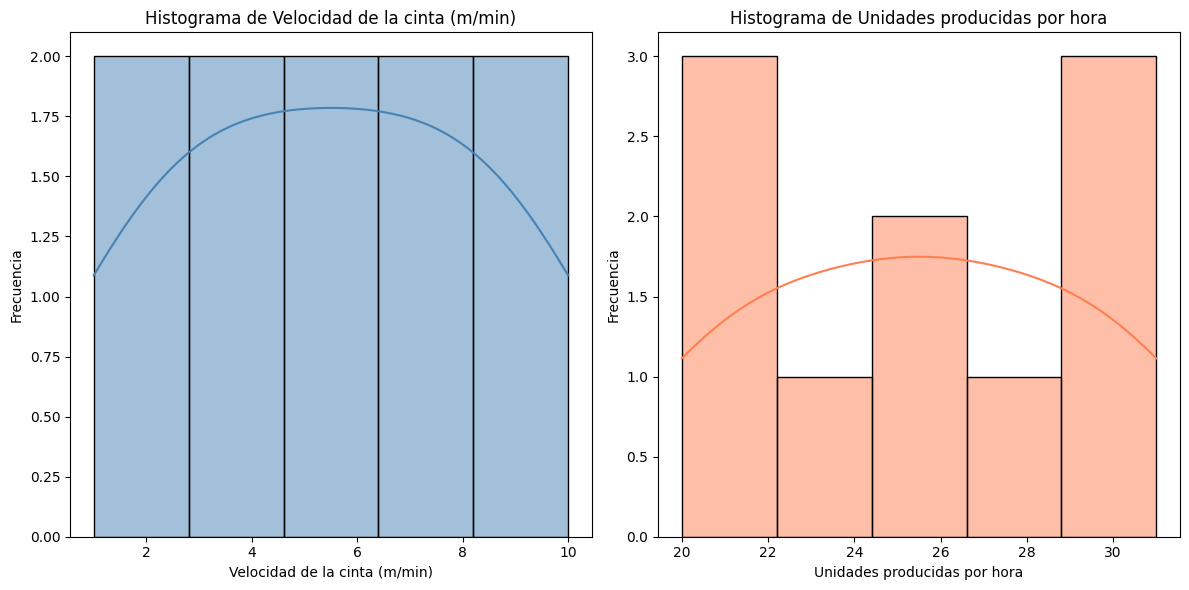

------------------------------
Generating Scatter Plot...


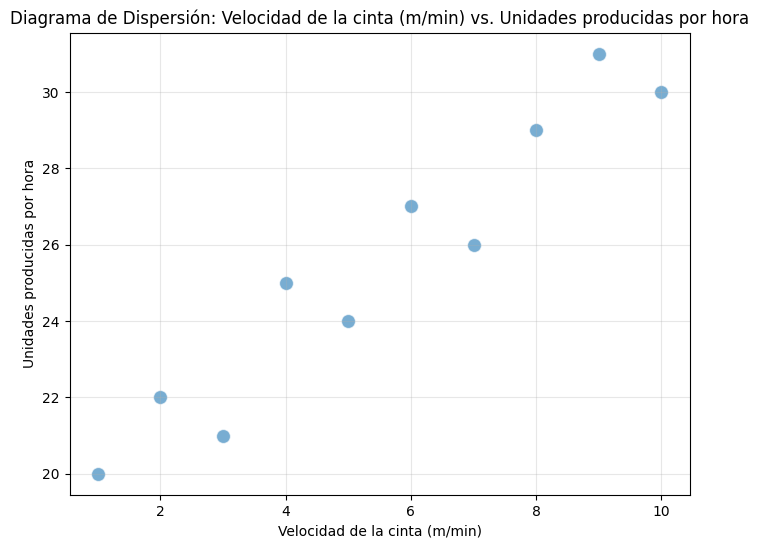

------------------------------
Performing Normality Tests...
Shapiro-Wilk test for 'Velocidad de la cinta (m/min)': Statistics=0.970, p-value=0.892
Shapiro-Wilk test for 'Unidades producidas por hora': Statistics=0.958, p-value=0.761

Interpretation of normality test results:
✓ The 'Velocidad de la cinta (m/min)' variable appears to be normally distributed (p > 0.05).
✓ The 'Unidades producidas por hora' variable appears to be normally distributed (p > 0.05).
------------------------------
Calculating Correlation Coefficients...
Pearson correlation coefficient: 0.9589
Kendall correlation coefficient: 0.8222
Spearman correlation coefficient: 0.9515
------------------------------
Determining the most appropriate correlation coefficient...
✓ Both variables appear normally distributed. The Pearson correlation coefficient (0.9589) is the most appropriate.
----------------------------------------------------------------------

--- PRUEBA DE HIPÓTESIS PARA EL COEFICIENTE DE CORRELACIÓN ---

H

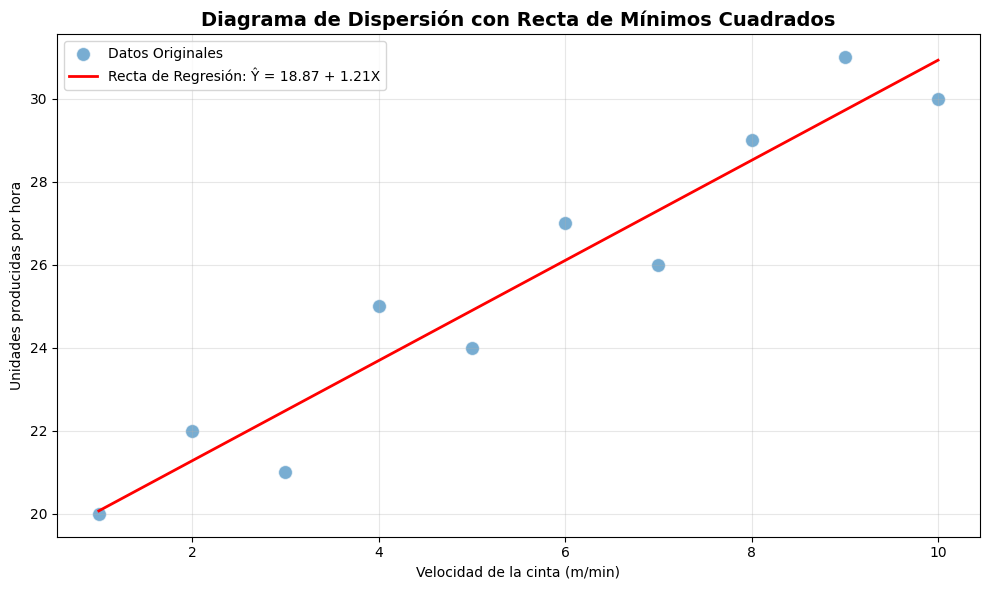


--- PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---

Hipótesis:
H0: β = 0 (No hay relación lineal significativa)
H1: β > 0 (Existe una relación lineal positiva significativa)

1. Cálculo del Error Estándar de Estimación (s_y,x):
   Σ(y - ŷ)² = 10.4970
   s_y,x = √[Σ(y - ŷ)² / (n - 2)] = 1.1455

2. Cálculo del Error Estándar de la Pendiente (s_b):
   Σ(x - x̄)² = 82.5000
   s_b = s_y,x / √[Σ(x - x̄)²] = 0.1261

3. Cálculo del Estadístico t:
   t = (b₁ - 0) / s_b = (1.2061 - 0) / 0.1261
   t calculado = 9.5633

4. Parámetros de la Prueba:
   Nivel de significancia (α) = 0.05
   Grados de libertad (gl) = 8
   Valor crítico (t_0.05,8) = 1.8595
   Valor p (una cola) = 0.0000

----------------------------------------------------------------------
CRITERIO DE DECISIÓN:
----------------------------------------------------------------------
t calculado (9.5633) > t crítico (1.8595)
valor p (0.0000) < α (0.05)

DECISIÓN: RECHAZAR H0
INTERPRETACIÓN: ✓ La pendiente ES significativamente diferente de 

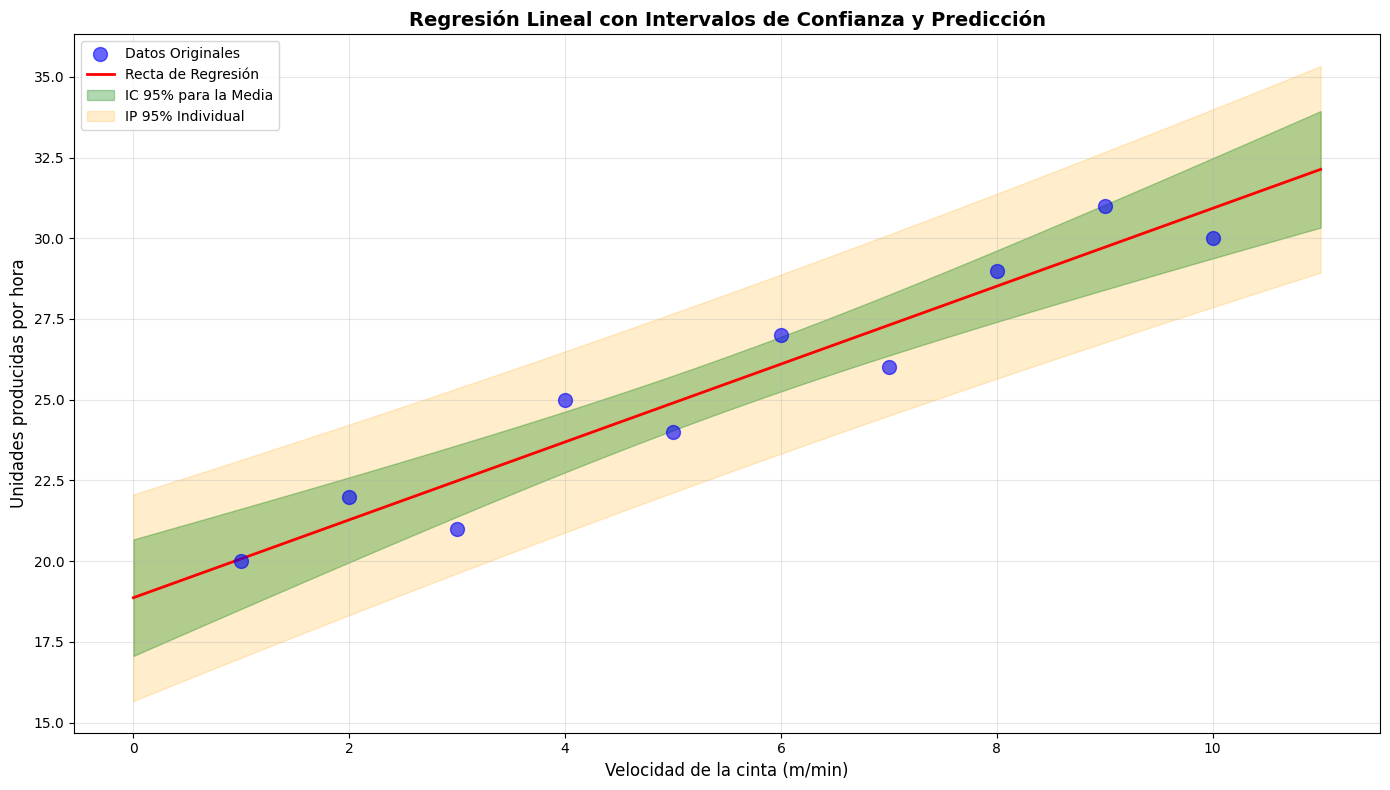

Visualización generada exitosamente!

--- ANÁLISIS DE RESIDUOS ---

Tabla de Residuos:

X        Y        ŷ        Residuo    Res. Std. 
------------------------------------------------------
1.0      20.0     20.07    -0.07      -0.06     
2.0      22.0     21.28    0.72       0.63      
3.0      21.0     22.48    -1.48      -1.30     
4.0      25.0     23.69    1.31       1.14      
5.0      24.0     24.90    -0.90      -0.78     
6.0      27.0     26.10    0.90       0.78      
7.0      26.0     27.31    -1.31      -1.14     
8.0      29.0     28.52    0.48       0.42      
9.0      31.0     29.72    1.28       1.12      
10.0     30.0     30.93    -0.93      -0.81     

Estadísticas de los Residuos:
  Media de residuos: -0.0000 (debe ser ≈ 0)
  Desviación estándar: 1.0800
  Residuo mínimo: -1.4848
  Residuo máximo: 1.3091


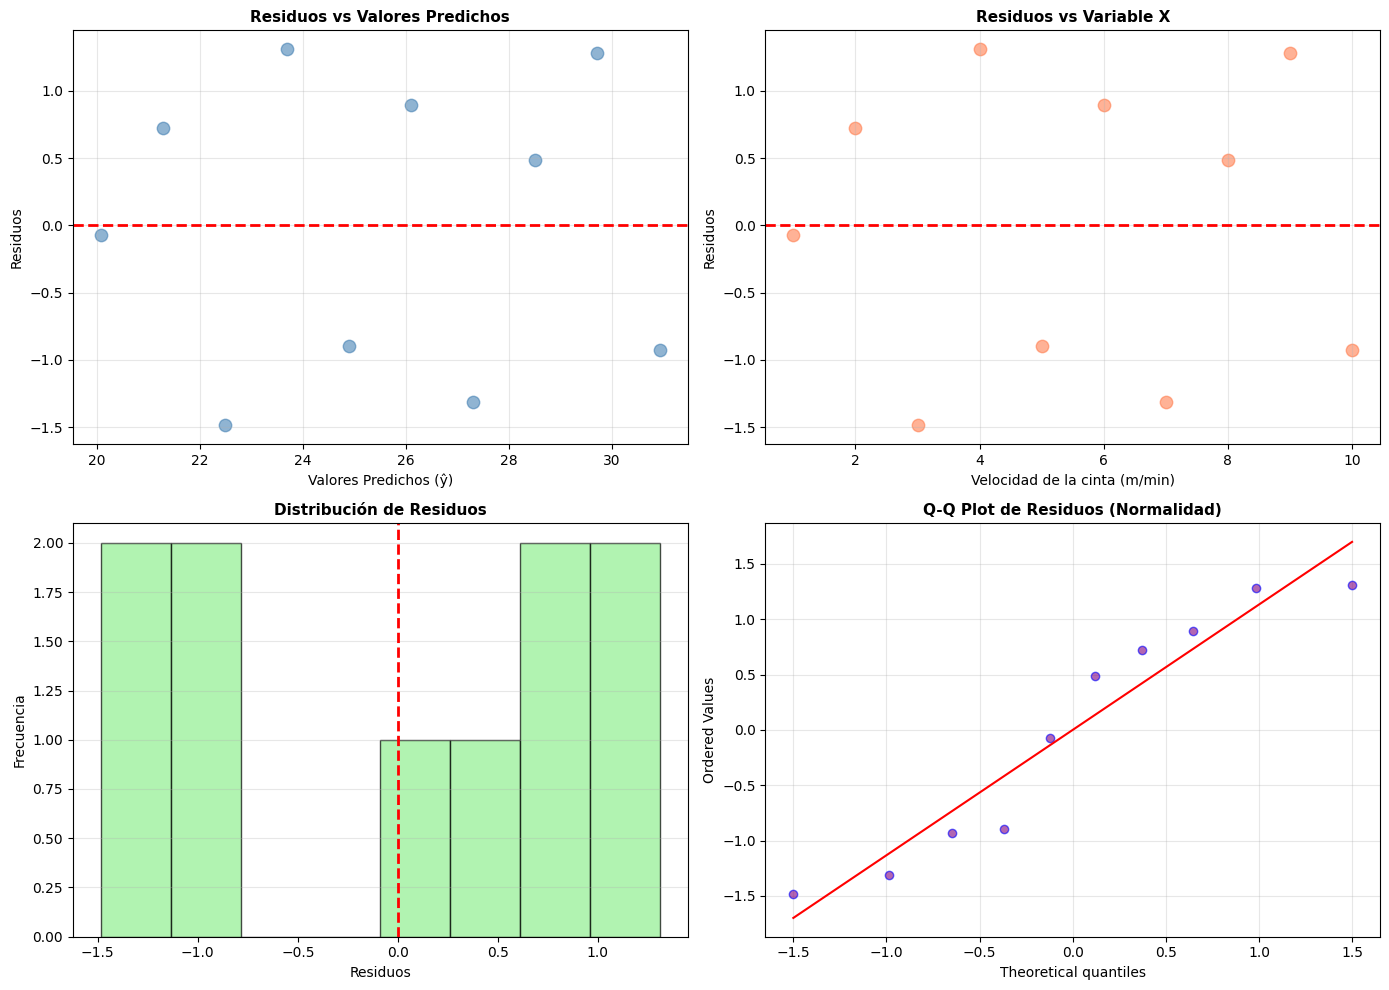


Prueba de Normalidad de Residuos (Shapiro-Wilk):
  Estadístico W = 0.8957
  Valor p = 0.1965
  ✓ Los residuos parecen seguir una distribución normal (p > 0.05)
    El supuesto de normalidad se cumple.

Interpretación de los gráficos de residuos:
  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.
  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.
  3. Histograma: Debe parecer aproximadamente normal (forma de campana).
  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.


--- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---

Criterios para evaluar si se necesita transformación:
----------------------------------------------------------------------

1. NORMALIDAD DE LAS VARIABLES:
   • Velocidad de la cinta (m/min): p-value = 0.8924
     ✓ Distribución normal
   • Unidades producidas por hora: p-value = 0.7615
     ✓ Distribución normal

2. NORMALIDAD DE LOS RESIDUOS:
   • Residuos: p-value = 0.1965
     ✓ Distribución normal



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, t, f as f_dist
from scipy import stats
import numpy as np

# --- DATAFRAME DEL PROBLEMA (VELOCIDAD DE LA CINTA Y UNIDADES PRODUCIDAS) ---
data = {
    'Velocidad de la cinta (m/min)': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Unidades producidas por hora': [20, 22, 21, 25, 24, 27, 26, 29, 31, 30]
}
df = pd.DataFrame(data)

variable_x = 'Velocidad de la cinta (m/min)'
variable_y = 'Unidades producidas por hora'
n = len(df)
alfa = 0.05

# =========================================================================
# --- ENCABEZADO ---
# =========================================================================
print("=" * 70)
print("ANÁLISIS DE REGRESIÓN LINEAL SIMPLE")
print("Problema: Velocidad de la Cinta vs. Unidades Producidas")
print("=" * 70)
print(f"\nDatos cargados: {n} observaciones")
print(f"Variable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"Nivel de significancia (α): {alfa}")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---
# =========================================================================
print("\n--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---")

# 1. Histograms
print("\nGenerating Histograms...")
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[variable_x], kde=True, color='steelblue')
plt.title(f'Histograma de {variable_x}')
plt.xlabel(variable_x)
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df[variable_y], kde=True, color='coral')
plt.title(f'Histograma de {variable_y}')
plt.xlabel(variable_y)
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()
print("-" * 30)

# 2. Scatter Plot
print("Generating Scatter Plot...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, s=100, alpha=0.6)
plt.title(f'Diagrama de Dispersión: {variable_x} vs. {variable_y}')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.grid(True, alpha=0.3)
plt.show()
print("-" * 30)

# 3. Normality Tests (Shapiro-Wilk)
print("Performing Normality Tests...")
shapiro_test_calls = shapiro(df[variable_x])
print(f"Shapiro-Wilk test for '{variable_x}': Statistics={shapiro_test_calls.statistic:.3f}, p-value={shapiro_test_calls.pvalue:.3f}")

shapiro_test_sold = shapiro(df[variable_y])
print(f"Shapiro-Wilk test for '{variable_y}': Statistics={shapiro_test_sold.statistic:.3f}, p-value={shapiro_test_sold.pvalue:.3f}")

print("\nInterpretation of normality test results:")
if shapiro_test_calls.pvalue > alfa:
    print(f"✓ The '{variable_x}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_x}' variable does not appear to be normally distributed (p <= 0.05).")

if shapiro_test_sold.pvalue > alfa:
    print(f"✓ The '{variable_y}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_y}' variable does not appear to be normally distributed (p <= 0.05).")
print("-" * 30)

# 4. Calculate Correlation Coefficients
print("Calculating Correlation Coefficients...")
pearson_corr = df[variable_x].corr(df[variable_y], method='pearson')
kendall_corr = df[variable_x].corr(df[variable_y], method='kendall')
spearman_corr = df[variable_x].corr(df[variable_y], method='spearman')

print(f"Pearson correlation coefficient: {pearson_corr:.4f}")
print(f"Kendall correlation coefficient: {kendall_corr:.4f}")
print(f"Spearman correlation coefficient: {spearman_corr:.4f}")
print("-" * 30)

# 5. Determine the most appropriate correlation coefficient
print("Determining the most appropriate correlation coefficient...")
if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
    print(f"✓ Both variables appear normally distributed. The Pearson correlation coefficient ({pearson_corr:.4f}) is the most appropriate.")
else:
     print(f"⚠ At least one variable does not appear normally distributed. The Spearman correlation coefficient ({spearman_corr:.4f}) or Kendall correlation coefficient ({kendall_corr:.4f}) are more appropriate non-parametric measures.")
print("-" * 70)

# =========================================================================
# --- PARTE 1: PRUEBA DE HIPÓTESIS PARA LA CORRELACIÓN ---
# =========================================================================

# Hipótesis: H0: rho = 0, H1: rho != 0 (Prueba de dos colas)
r = pearson_corr
gl = n - 2  # Grados de libertad

# Fórmula: t = r * sqrt(n - 2) / sqrt(1 - r^2)
t_calculado = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)

# Valor p (two-sided)
valor_p = t.sf(abs(t_calculado), gl) * 2

# Valor crítico de t (para alfa/2)
t_critico_positivo = t.ppf(1 - alfa / 2, gl)
t_critico_negativo = -t_critico_positivo

print("\n" + "=" * 70)
print("--- PRUEBA DE HIPÓTESIS PARA EL COEFICIENTE DE CORRELACIÓN ---")
print("=" * 70)
print(f"\nHipótesis:")
print(f"H0: ρ = 0 (No existe correlación lineal)")
print(f"H1: ρ ≠ 0 (Existe correlación lineal)")
print(f"\nNúmero de observaciones (n): {n}")
print(f"Grados de libertad (gl): {gl}")
print(f"Coeficiente de correlación de Pearson (r): {r:.4f}")
print(f"Estadístico t calculado: {t_calculado:.4f}")
print(f"Valor crítico (t, α={alfa}): ±{t_critico_positivo:.4f}")
print(f"Valor p: {valor_p:.4f}")

# Criterio de Decisión
if valor_p < alfa:
    decision_hipotesis = "RECHAZAR H0"
    conclusion = "✓ Existe una correlación lineal significativa (ρ ≠ 0)."
else:
    decision_hipotesis = "NO RECHAZAR H0"
    conclusion = "✗ No hay evidencia de una correlación lineal significativa (ρ = 0)."

print(f"\nDECISIÓN (Valor p < {alfa}): {decision_hipotesis}")
print(f"CONCLUSIÓN: {conclusion}")
print("=" * 70)

# =========================================================================
# --- PARTE 2: RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---
# =========================================================================

# Cálculo de la media de X (Número de llamadas) y Y (Copiadoras vendidas)
mean_x = df[variable_x].mean()
mean_y = df[variable_y].mean()

# 1. Cálculo de la PENDIENTE (b1)
# b1 = r * (Sy / Sx)
std_x = df[variable_x].std(ddof=1)  # Desviación estándar muestral
std_y = df[variable_y].std(ddof=1)  # Desviación estándar muestral
b1 = r * (std_y / std_x)

# 2. Cálculo de la INTERSECCIÓN CON EL EJE Y (b0)
# b0 = mean_y - b1 * mean_x
b0 = mean_y - b1 * mean_x

print("\n" + "=" * 70)
print("--- RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---")
print("=" * 70)
print(f"\nVariable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"\nEstadísticos Descriptivos:")
print(f"Media de X (x̄): {mean_x:.2f}")
print(f"Media de Y (ȳ): {mean_y:.2f}")
print(f"Desviación estándar de X (Sx): {std_x:.2f}")
print(f"Desviación estándar de Y (Sy): {std_y:.2f}")

print(f"\nCoeficientes de Regresión:")
print(f"PENDIENTE (b₁): {b1:.4f}")
print(f"INTERSECCIÓN (b₀): {b0:.4f}")

print("\n┌─────────────────────────────────────────────────────┐")
print(f"│  ECUACIÓN DE REGRESIÓN:                             │")
print(f"│  Ŷ = {b0:.4f} + {b1:.4f} * X                  │")
print("└─────────────────────────────────────────────────────┘")
print("=" * 70)

# --- Visualización de la Recta de Regresión ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, label='Datos Originales', s=100, alpha=0.6)

# Crear la línea de regresión
x_min = df[variable_x].min()
x_max = df[variable_x].max()
x_line = np.linspace(x_min, x_max, 100)
y_line = b0 + b1 * x_line

plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Recta de Regresión: Ŷ = {b0:.2f} + {b1:.2f}X')
plt.title('Diagrama de Dispersión con Recta de Mínimos Cuadrados', fontsize=14, fontweight='bold')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================================
# --- PARTE 3: PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---
# =========================================================================

print("\n" + "=" * 70)
print("--- PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---")
print("=" * 70)

# Hipótesis:
# H0: β = 0 (La pendiente no es significativamente diferente de cero)
# H1: β > 0 (La pendiente es significativamente mayor que cero)

print("\nHipótesis:")
print("H0: β = 0 (No hay relación lineal significativa)")
print("H1: β > 0 (Existe una relación lineal positiva significativa)")

# Calcular valores predichos (ŷ)
df['y_predicho'] = b0 + b1 * df[variable_x]

# Calcular el Error Estándar de Estimación (s_y,x)
# Fórmula: s_y,x = sqrt(Σ(y - ŷ)² / (n - 2))
diferencias_cuadradas = (df[variable_y] - df['y_predicho']) ** 2
suma_diferencias_cuadradas = diferencias_cuadradas.sum()
s_yx = np.sqrt(suma_diferencias_cuadradas / (n - 2))

print(f"\n1. Cálculo del Error Estándar de Estimación (s_y,x):")
print(f"   Σ(y - ŷ)² = {suma_diferencias_cuadradas:.4f}")
print(f"   s_y,x = √[Σ(y - ŷ)² / (n - 2)] = {s_yx:.4f}")

# Calcular el Error Estándar de la Pendiente (s_b)
# Fórmula: s_b = s_y,x / sqrt(Σ(x - x̄)²)
desviaciones_x = (df[variable_x] - mean_x) ** 2
suma_desviaciones_x = desviaciones_x.sum()
s_b = s_yx / np.sqrt(suma_desviaciones_x)

print(f"\n2. Cálculo del Error Estándar de la Pendiente (s_b):")
print(f"   Σ(x - x̄)² = {suma_desviaciones_x:.4f}")
print(f"   s_b = s_y,x / √[Σ(x - x̄)²] = {s_b:.4f}")

# Calcular el estadístico t
# Fórmula: t = (b - 0) / s_b
t_calculado_pendiente = (b1 - 0) / s_b

print(f"\n3. Cálculo del Estadístico t:")
print(f"   t = (b₁ - 0) / s_b = ({b1:.4f} - 0) / {s_b:.4f}")
print(f"   t calculado = {t_calculado_pendiente:.4f}")

# Grados de libertad
gl_pendiente = n - 2

# Valor crítico (prueba de una cola, cola derecha)
t_critico_pendiente = t.ppf(1 - alfa, gl_pendiente)

# Valor p (prueba de una cola)
valor_p_pendiente = t.sf(t_calculado_pendiente, gl_pendiente)

print(f"\n4. Parámetros de la Prueba:")
print(f"   Nivel de significancia (α) = {alfa}")
print(f"   Grados de libertad (gl) = {gl_pendiente}")
print(f"   Valor crítico (t_{alfa},{gl_pendiente}) = {t_critico_pendiente:.4f}")
print(f"   Valor p (una cola) = {valor_p_pendiente:.4f}")

# Criterio de Decisión
print("\n" + "-" * 70)
print("CRITERIO DE DECISIÓN:")
print("-" * 70)

if valor_p_pendiente < alfa:
    decision_pendiente = "RECHAZAR H0"
    interpretacion = "✓ La pendiente ES significativamente diferente de cero."
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) < α ({alfa}), rechazamos la hipótesis nula.
    Esto significa que existe evidencia estadística suficiente para concluir que
    el {variable_x} tiene un efecto significativo POSITIVO sobre
    el {variable_y}.

    En términos prácticos: Por cada unidad adicional de {variable_x}, se espera un
    incremento de {b1:.4f} {variable_y}, y este efecto es estadísticamente
    significativo.
    """
else:
    decision_pendiente = "NO RECHAZAR H0"
    interpretacion = "✗ La pendiente NO es significativamente diferente de cero."
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) ≥ α ({alfa}), no rechazamos la hipótesis nula.
    No hay evidencia estadística suficiente para concluir que el {variable_x}
    tenga un efecto significativo sobre el {variable_y}.
    """

print(f"t calculado ({t_calculado_pendiente:.4f}) {'>' if t_calculado_pendiente > t_critico_pendiente else '<'} t crítico ({t_critico_pendiente:.4f})")
print(f"valor p ({valor_p_pendiente:.4f}) {'<' if valor_p_pendiente < alfa else '≥'} α ({alfa})")
print(f"\nDECISIÓN: {decision_pendiente}")
print(f"INTERPRETACIÓN: {interpretacion}")

print("\n" + "=" * 70)
print("CONCLUSIÓN FINAL:")
print("=" * 70)
print(conclusion_pendiente)

# =========================================================================
# --- COEFICIENTE DE DETERMINACIÓN (R²) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- COEFICIENTE DE DETERMINACIÓN (R²) ---")
print("=" * 70)

# Cálculo de R²
# R² = 1 - (SSE / SS Total)
# donde SSE = Σ(y - ŷ)² y SS Total = Σ(y - ȳ)²

SSE = suma_diferencias_cuadradas  # Ya calculado anteriormente
SS_Total = ((df[variable_y] - mean_y) ** 2).sum()
SSR = SS_Total - SSE

r_cuadrado = 1 - (SSE / SS_Total)
# También: r_cuadrado = r ** 2

print(f"\nSuma de Cuadrados:")
print(f"  SS Total (Variabilidad total)     = {SS_Total:.4f}")
print(f"  SSR (Explicada por regresión)     = {SSR:.4f}")
print(f"  SSE (No explicada - Error)        = {SSE:.4f}")

print(f"\nCálculo de R²:")
print(f"  R² = 1 - (SSE / SS Total)")
print(f"  R² = 1 - ({SSE:.4f} / {SS_Total:.4f})")
print(f"  R² = {r_cuadrado:.4f}")

print(f"\nVerificación: R² = r² = ({r:.4f})² = {r**2:.4f}")

print(f"\n┌─────────────────────────────────────────────────────────────────┐")
print(f"│  INTERPRETACIÓN DE R²:                                          │")
print(f"│  El {r_cuadrado*100:.2f}% de la variabilidad en el {variable_y}            │")
print(f"│  puede ser explicada por el {variable_x}.                     │")
print(f"└─────────────────────────────────────────────────────────────────┘")

print("\n" + "=" * 70)

# =========================================================================
# --- TABLA ANOVA DE REGRESIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- TABLA ANOVA DE REGRESIÓN ---")
print("=" * 70)

# Calcular cuadrados medios
MSR = SSR / 1  # 1 grado de libertad para regresión
MSE = SSE / (n - 2)  # n-2 grados de libertad para error

# Estadístico F
F_calculado = MSR / MSE

# Valor p del estadístico F
valor_p_f = f_dist.sf(F_calculado, 1, n - 2)

print(f"\n{'Fuente':<20} {'SS':<15} {'gl':<10} {'MS':<15} {'F':<15} {'Valor p':<15}")
print("-" * 90)
print(f"{'Regresión':<20} {SSR:<15.4f} {1:<10} {MSR:<15.4f} {F_calculado:<15.4f} {valor_p_f:<15.6f}")
print(f"{'Error':<20} {SSE:<15.4f} {n-2:<10} {MSE:<15.4f}")
print(f"{'Total':<20} {SS_Total:<15.4f} {n-1:<10}")

print(f"\nINTERPRETACIÓN:")
if valor_p_f < alfa:
    print(f"✓ El modelo de regresión ES significativo (p = {valor_p_f:.6f} < {alfa})")
    print("  El modelo es útil para hacer predicciones.")
else:
    print(f"✗ El modelo de regresión NO es significativo (p = {valor_p_f:.6f} ≥ {alfa})")
    print("  El modelo NO es útil para hacer predicciones.")

print("=" * 70)

# =========================================================================
# --- PARTE 4: INTERVALOS DE CONFIANZA Y PREDICCIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- INTERVALOS DE CONFIANZA Y PREDICCIÓN ---")
print("=" * 70)

# Valor crítico t para intervalos (dos colas)
t_critico_intervalo = t.ppf(1 - alfa/2, gl_pendiente)
print(f"\nValor crítico t para intervalos (α={alfa}, gl={gl_pendiente}): ±{t_critico_intervalo:.4f}")

# =========================================================================
# A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1/n + (x - x̄)² / Σ(x - x̄)²]")

# Ejemplo: Calcular intervalo para algunos valores de X
valores_x_ejemplo = [df[variable_x].min(), df[variable_x].mean(), df[variable_x].median(), df[variable_x].max()]  # Ejemplos de velocidad de cinta

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de confianza para la MEDIA de {variable_y}:\n")
print(f"{'X (' + variable_x + ')':<15} {'ŷ (Predicción)':<20} {'Intervalo de Confianza':<35}")
print("-" * 70)

intervalos_confianza = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error
    termino_error = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_conf = t_critico_intervalo * s_yx * termino_error

    # Límites del intervalo
    limite_inferior_conf = y_pred - margen_conf
    limite_superior_conf = y_pred + margen_conf

    intervalos_confianza.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_conf,
        'limite_sup': limite_superior_conf
    })

    print(f"{x_val:<15.1f} {y_pred:<20.2f} [{limite_inferior_conf:.2f}, {limite_superior_conf:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, cuando se tiene X {variable_x},")
print(f"la MEDIA de {variable_y} estará dentro del intervalo calculado.")

# =========================================================================
# B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1 + 1/n + (x - x̄)² / Σ(x - x̄)²]")

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de predicción para {variable_y} INDIVIDUALES:\n")
print(f"{'X (' + variable_x + ')':<15} {'ŷ (Predicción)':<20} {'Intervalo de Predicción':<35}")
print("-" * 70)

intervalos_prediccion = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error (NOTA: incluye el 1 + ...)
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred

    # Límites del intervalo
    limite_inferior_pred = y_pred - margen_pred
    limite_superior_pred = y_pred + margen_pred

    intervalos_prediccion.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_pred,
        'limite_sup': limite_superior_pred
    })

    print(f"{x_val:<15.1f} {y_pred:<20.2f} [{limite_inferior_pred:.2f}, {limite_superior_pred:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, cuando se tiene X {variable_x},")
print(f"una observación INDIVIDUAL de {variable_y} estará dentro del intervalo calculado.")

# =========================================================================
# COMPARACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("COMPARACIÓN: INTERVALO DE CONFIANZA vs INTERVALO DE PREDICCIÓN")
print("=" * 70)

print("\n📊 Diferencias clave:")
print("\n1. INTERVALO DE CONFIANZA (para la media):")
print("   - Más ESTRECHO")
print("   - Estima dónde está la MEDIA de Y para un valor dado de X")
print("   - Útil para entender la relación promedio")

print("\n2. INTERVALO DE PREDICCIÓN (para un valor individual):")
print("   - Más AMPLIO")
print("   - Predice dónde estará una OBSERVACIÓN INDIVIDUAL de Y")
print("   - Útil para hacer predicciones específicas")

print("\n3. ¿Por qué el intervalo de predicción es más amplio?")
print("   - Incluye la incertidumbre de la media (como el de confianza)")
print("   - ADEMÁS incluye la variabilidad individual alrededor de esa media")

# =========================================================================
# VISUALIZACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("Generando visualización de intervalos...")

plt.figure(figsize=(14, 8))

# Datos originales
plt.scatter(df[variable_x], df[variable_y],
           color='blue', s=100, alpha=0.6, label='Datos Originales', zorder=3)

# Recta de regresión
x_range = np.linspace(df[variable_x].min() - 1, df[variable_x].max() + 1, 100)
y_range = b0 + b1 * x_range
plt.plot(x_range, y_range, 'r-', linewidth=2, label='Recta de Regresión', zorder=2)

# Calcular intervalos para todo el rango
ic_lower = []
ic_upper = []
ip_lower = []
ip_upper = []

for x_val in x_range:
    y_pred = b0 + b1 * x_val

    # Intervalo de confianza
    termino_error_conf = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_conf = t_critico_intervalo * s_yx * termino_error_conf
    ic_lower.append(y_pred - margen_conf)
    ic_upper.append(y_pred + margen_conf)

    # Intervalo de predicción
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred
    ip_lower.append(y_pred - margen_pred)
    ip_upper.append(y_pred + margen_pred)

# Graficar intervalos de confianza
plt.fill_between(x_range, ic_lower, ic_upper,
                alpha=0.3, color='green',
                label=f'IC {(1-alfa)*100:.0f}% para la Media', zorder=1)

# Graficar intervalos de predicción
plt.fill_between(x_range, ip_lower, ip_upper,
                alpha=0.2, color='orange',
                label=f'IP {(1-alfa)*100:.0f}% Individual', zorder=0)

plt.xlabel(variable_x, fontsize=12)
plt.ylabel(variable_y, fontsize=12)
plt.title('Regresión Lineal con Intervalos de Confianza y Predicción', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Visualización generada exitosamente!")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DE RESIDUOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- ANÁLISIS DE RESIDUOS ---")
print("=" * 70)

# Calcular residuos
df['residuos'] = df[variable_y] - df['y_predicho']
df['residuos_estandarizados'] = df['residuos'] / s_yx

print("\nTabla de Residuos:")
print(f"\n{'X':<8} {'Y':<8} {'ŷ':<8} {'Residuo':<10} {'Res. Std.':<10}")
print("-" * 54)
for idx, row in df.iterrows():
    print(f"{row[variable_x]:<8} {row[variable_y]:<8} "
          f"{row['y_predicho']:<8.2f} {row['residuos']:<10.2f} {row['residuos_estandarizados']:<10.2f}")

# Estadísticas de residuos
print(f"\nEstadísticas de los Residuos:")
print(f"  Media de residuos: {df['residuos'].mean():.4f} (debe ser ≈ 0)")
print(f"  Desviación estándar: {df['residuos'].std():.4f}")
print(f"  Residuo mínimo: {df['residuos'].min():.4f}")
print(f"  Residuo máximo: {df['residuos'].max():.4f}")

# Gráficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Valores Predichos
axes[0, 0].scatter(df['y_predicho'], df['residuos'], alpha=0.6, s=80, color='steelblue')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Valores Predichos (ŷ)', fontsize=10)
axes[0, 0].set_ylabel('Residuos', fontsize=10)
axes[0, 0].set_title('Residuos vs Valores Predichos', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuos vs Variable X
axes[0, 1].scatter(df[variable_x], df['residuos'], alpha=0.6, s=80, color='coral')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel(variable_x, fontsize=10)
axes[0, 1].set_ylabel('Residuos', fontsize=10)
axes[0, 1].set_title('Residuos vs Variable X', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histograma de Residuos
axes[1, 0].hist(df['residuos'], bins=8, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1, 0].set_xlabel('Residuos', fontsize=10)
axes[1, 0].set_ylabel('Frecuencia', fontsize=10)
axes[1, 0].set_title('Distribución de Residuos', fontsize=11, fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Q-Q Plot de Residuos
stats.probplot(df['residuos'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot de Residuos (Normalidad)', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].get_lines()[0].set_markerfacecolor('purple')
axes[1, 1].get_lines()[0].set_markersize(6)
axes[1, 1].get_lines()[0].set_alpha(0.6)

plt.tight_layout()
plt.show()

# Prueba de normalidad de residuos
shapiro_residuos = shapiro(df['residuos'])
print(f"\nPrueba de Normalidad de Residuos (Shapiro-Wilk):")
print(f"  Estadístico W = {shapiro_residuos.statistic:.4f}")
print(f"  Valor p = {shapiro_residuos.pvalue:.4f}")

if shapiro_residuos.pvalue > alfa:
    print(f"  ✓ Los residuos parecen seguir una distribución normal (p > {alfa})")
    print("    El supuesto de normalidad se cumple.")
else:
    print(f"  ✗ Los residuos NO parecen seguir una distribución normal (p ≤ {alfa})")
    print("    El supuesto de normalidad puede no cumplirse.")

print("\nInterpretación de los gráficos de residuos:")
print("  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.")
print("  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.")
print("  3. Histograma: Debe parecer aproximadamente normal (forma de campana).")
print("  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.")

print("\n" + "=" * 70)

# =========================================================================
# --- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---")
print("=" * 70)

print("\nCriterios para evaluar si se necesita transformación:")
print("-" * 70)

# 1. Normalidad de las variables
print("\n1. NORMALIDAD DE LAS VARIABLES:")
print(f"   • {variable_x}: p-value = {shapiro_test_calls.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_calls.pvalue > alfa else '✗ No normal'}")
print(f"   • {variable_y}: p-value = {shapiro_test_sold.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_sold.pvalue > alfa else '✗ No normal'}")

# 2. Normalidad de residuos
print(f"\n2. NORMALIDAD DE LOS RESIDUOS:")
print(f"   • Residuos: p-value = {shapiro_residuos.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_residuos.pvalue > alfa else '✗ No normal'}")

# 3. Homocedasticidad (inspección visual)
print(f"\n3. HOMOCEDASTICIDAD (Varianza constante):")
print(f"   • Revisar gráfico 'Residuos vs Valores Predichos'")
print(f"   • Si los residuos muestran patrón de embudo o cono → transformar")
print(f"   • Si los residuos están distribuidos aleatoriamente → no transformar")

# 4. Linealidad
print(f"\n4. LINEALIDAD DE LA RELACIÓN:")
print(f"   • Revisar diagrama de dispersión X vs Y")
print(f"   • Coeficiente de correlación: r = {r:.4f}")
print(f"     {'✓ Relación lineal adecuada' if abs(r) > 0.6 else '⚠ Relación débil, considerar transformación'}")

# 5. Valores atípicos
residuos_estandarizados = np.abs(df['residuos_estandarizados'])
outliers = df[residuos_estandarizados > 2.5]
print(f"\n5. VALORES ATÍPICOS:")
print(f"   • Número de residuos estandarizados > 2.5: {len(outliers)}")
if len(outliers) > 0:
    print(f"   • Observaciones con residuos atípicos (X, Y):")
    for idx, row in outliers.iterrows():
        print(f"     - ({row[variable_x]}, {row[variable_y]}): residuo std = {row['residuos_estandarizados']:.2f}")

# Decisión final
print("\n" + "=" * 70)
print("DECISIÓN SOBRE TRANSFORMACIÓN:")
print("=" * 70)

necesita_transformacion = False
razones_transformacion = []

if shapiro_test_calls.pvalue <= alfa or shapiro_test_sold.pvalue <= alfa:
    razones_transformacion.append("- Variables originales no son normales")
    necesita_transformacion = True

if shapiro_residuos.pvalue <= alfa:
    razones_transformacion.append("- Residuos no siguen distribución normal")
    necesita_transformacion = True

if abs(r) < 0.5:
    razones_transformacion.append("- Correlación lineal débil (r < 0.5)")
    necesita_transformacion = True

if len(outliers) > n * 0.15:  # Más del 15% son outliers
    razones_transformacion.append(f"- Exceso de valores atípicos ({len(outliers)} casos)")
    necesita_transformacion = True

if necesita_transformacion:
    print("\n⚠ SE RECOMIENDA CONSIDERAR TRANSFORMACIÓN DE DATOS\n")
    print("Razones:")
    for razon in razones_transformacion:
        print(f"  {razon}")

    print("\nTransformaciones sugeridas:")
    print("  • Logarítmica: Y' = log(Y) o X' = log(X)")
    print("    └─ Útil para reducir asimetría positiva y estabilizar varianza")
    print("  • Raíz cuadrada: Y' = √Y")
    print("    └─ Útil para datos de conteo con varianza proporcional a la media")
    print("  • Recíproca: Y' = 1/Y")
    print("    └─ Útil para relaciones no lineales decrecientes")
    print("  • Box-Cox: Encuentra la transformación óptima automáticamente")

    print("\n  IMPORTANTE: Después de transformar, repetir todo el análisis")
    print("  con los datos transformados y comparar resultados.")

else:
    print("\n✓ NO ES NECESARIA LA TRANSFORMACIÓN DE DATOS\n")
    print("Justificación:")

    if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
        print("  ✓ Las variables originales son aproximadamente normales")

    if shapiro_residuos.pvalue > alfa:
        print("  ✓ Los residuos siguen una distribución normal")

    if abs(r) >= 0.6:
        print(f"  ✓ La correlación lineal es adecuada (r = {r:.4f})")

    if len(outliers) <= n * 0.15:
        print(f"  ✓ Número aceptable de valores atípicos ({len(outliers)} casos)")

    print("\n  El modelo de regresión lineal simple es apropiado para estos datos")
    print("  sin necesidad de transformaciones. Los supuestos fundamentales se")
    print("  cumplen razonablemente bien.")

print("\n" + "=" * 70)

# =========================================================================
# --- RESUMEN EJECUTIVO DEL ANÁLISIS ---
# =========================================================================

print("\n" + "=" * 70)
print("╔═════════════════════════════════════════════════════════════════╗")
print("║       RESUMEN EJECUTIVO DEL ANÁLISIS DE REGRESIÓN              ║")
print("╚═════════════════════════════════════════════════════════════════╝")
print("=" * 70)

print(f"""
📊 MODELO DE REGRESIÓN:
   Ecuación: Ŷ = {b0:.4f} + {b1:.4f} × X

   Interpretación:
   • El punto de partida (b₀) es {b0:.2f} {variable_y} cuando {variable_x} es 0
   • Por cada unidad adicional de {variable_x}, aumentan {b1:.4f} {variable_y}

📈 BONDAD DE AJUSTE:
   • Coeficiente de correlación (r): {r:.4f}
     └─ Correlación {'fuerte' if abs(r) > 0.7 else 'moderada' if abs(r) > 0.4 else 'débil'} {'positiva' if r > 0 else 'negativa'}

   • Coeficiente de determinación (R²): {r_cuadrado:.4f}
     └─ {r_cuadrado*100:.2f}% de la variabilidad explicada

   • Error estándar de estimación (s_y,x): {s_yx:.4f}
     └─ Error típico de predicción: ±{s_yx:.2f} {variable_y}

✅ PRUEBAS DE SIGNIFICANCIA (α = {alfa}):

   1. Correlación:
      • Estadístico t: {t_calculado:.4f}
      • Valor p: {valor_p:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p < alfa else '✗ NO SIGNIFICATIVA'}

   2. Pendiente:
      • Estadístico t: {t_calculado_pendiente:.4f}
      • Valor p: {valor_p_pendiente:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p_pendiente < alfa else '✗ NO SIGNIFICATIVA'}

   3. Modelo (ANOVA):
      • Estadístico F: {F_calculado:.4f}
      • Valor p: {valor_p_f:.6f}
      • Decisión: {'✓ MODELO SIGNIFICATIVO' if valor_p_f < alfa else '✗ MODELO NO SIGNIFICATIVO'}

🔍 VALIDACIÓN DE SUPUESTOS:
   • Normalidad de residuos: {'✓ CUMPLE' if shapiro_residuos.pvalue > alfa else '⚠ NO CUMPLE'} (p = {shapiro_residuos.pvalue:.4f})
   • Linealidad: {'✓ Verificar gráfico de dispersión' if abs(r) > 0.6 else '⚠ Revisar gráfico de dispersión'}
   • Homocedasticidad: {'✓ Verificar gráfico de residuos'}

💡 CONCLUSIÓN GENERAL:
""")

if valor_p_pendiente < alfa and valor_p_f < alfa:
    print(f"""   ✓ EL MODELO ES VÁLIDO Y ÚTIL PARA PREDICCIONES

   El {variable_x} es un predictor SIGNIFICATIVO del
   {variable_y}. El modelo explica {r_cuadrado*100:.2f}% de la
   variabilidad y puede utilizarse con confianza para:

   • Predecir {variable_y} futuras basadas en {variable_x} planificada
   • Establecer objetivos de {variable_x} para alcanzar metas de {variable_y}

   Recomendación: IMPLEMENTAR este modelo en la planificación.
""")
else:
    print(f"""   ⚠ EL MODELO TIENE LIMITACIONES

   Aunque existe una relación entre {variable_x} y {variable_y}, el modelo
   presenta algunas limitaciones estadísticas. Se recomienda:

   • Recolectar más datos para mejorar el modelo
   • Considerar otras variables explicativas
   • Realizar análisis adicionales antes de implementar decisiones
""")

print("\n" + "=" * 70)
print("📌 NOTA: Revise todos los gráficos generados para una interpretación")
print("   completa de los resultados y validación de supuestos.")
print("=" * 70)

print("\n✓ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 70)

        ANÁLISIS DE REGRESIÓN LINEAL - ENSAMBLAJE
n=10 | α=0.05 | X=Velocidad de la cinta (m/min) | Y=Unidades producidas por hora

--- ESTADÍSTICAS DESCRIPTIVAS Y CORRELACIÓN ---
X: μ=5.50, σ=3.03, rango=[1, 10]
Y: μ=25.50, σ=3.81, rango=[20, 31]

Normalidad (Shapiro-Wilk):
  X: p=0.8924 ✓ Normal
  Y: p=0.7615 ✓ Normal

Correlación: Pearson=0.9589 | Spearman=0.9515
Magnitud: Fuerte | Dirección: Positiva

--- PRUEBA DE CORRELACIÓN ---
H₀: ρ=0 vs H₁: ρ≠0 | t=9.563, t_crit=±2.306, p=0.0000
Decisión: ✓ Rechazar H₀ - Correlación SIGNIFICATIVA

--- MODELO DE REGRESIÓN ---
Ecuación: Ŷ = 18.8667 + 1.2061X
  b₀ (intersección): 18.8667 → Unidades base sin velocidad de cinta (cuando X=0)
  b₁ (pendiente): 1.2061 → Por cada unidad adicional de Velocidad de la cinta (m/min), +1.2061 Unidades producidas por hora

Bondad de ajuste:
  R² = 0.9196 (92.0% variabilidad explicada)
  Error estándar (s_y,x) = 1.1455

--- PRUEBAS DE SIGNIFICANCIA (α=0.05) ---
1. Pendiente: H₀: β=0 vs H₁: β≠0
   t=9.563, t_c

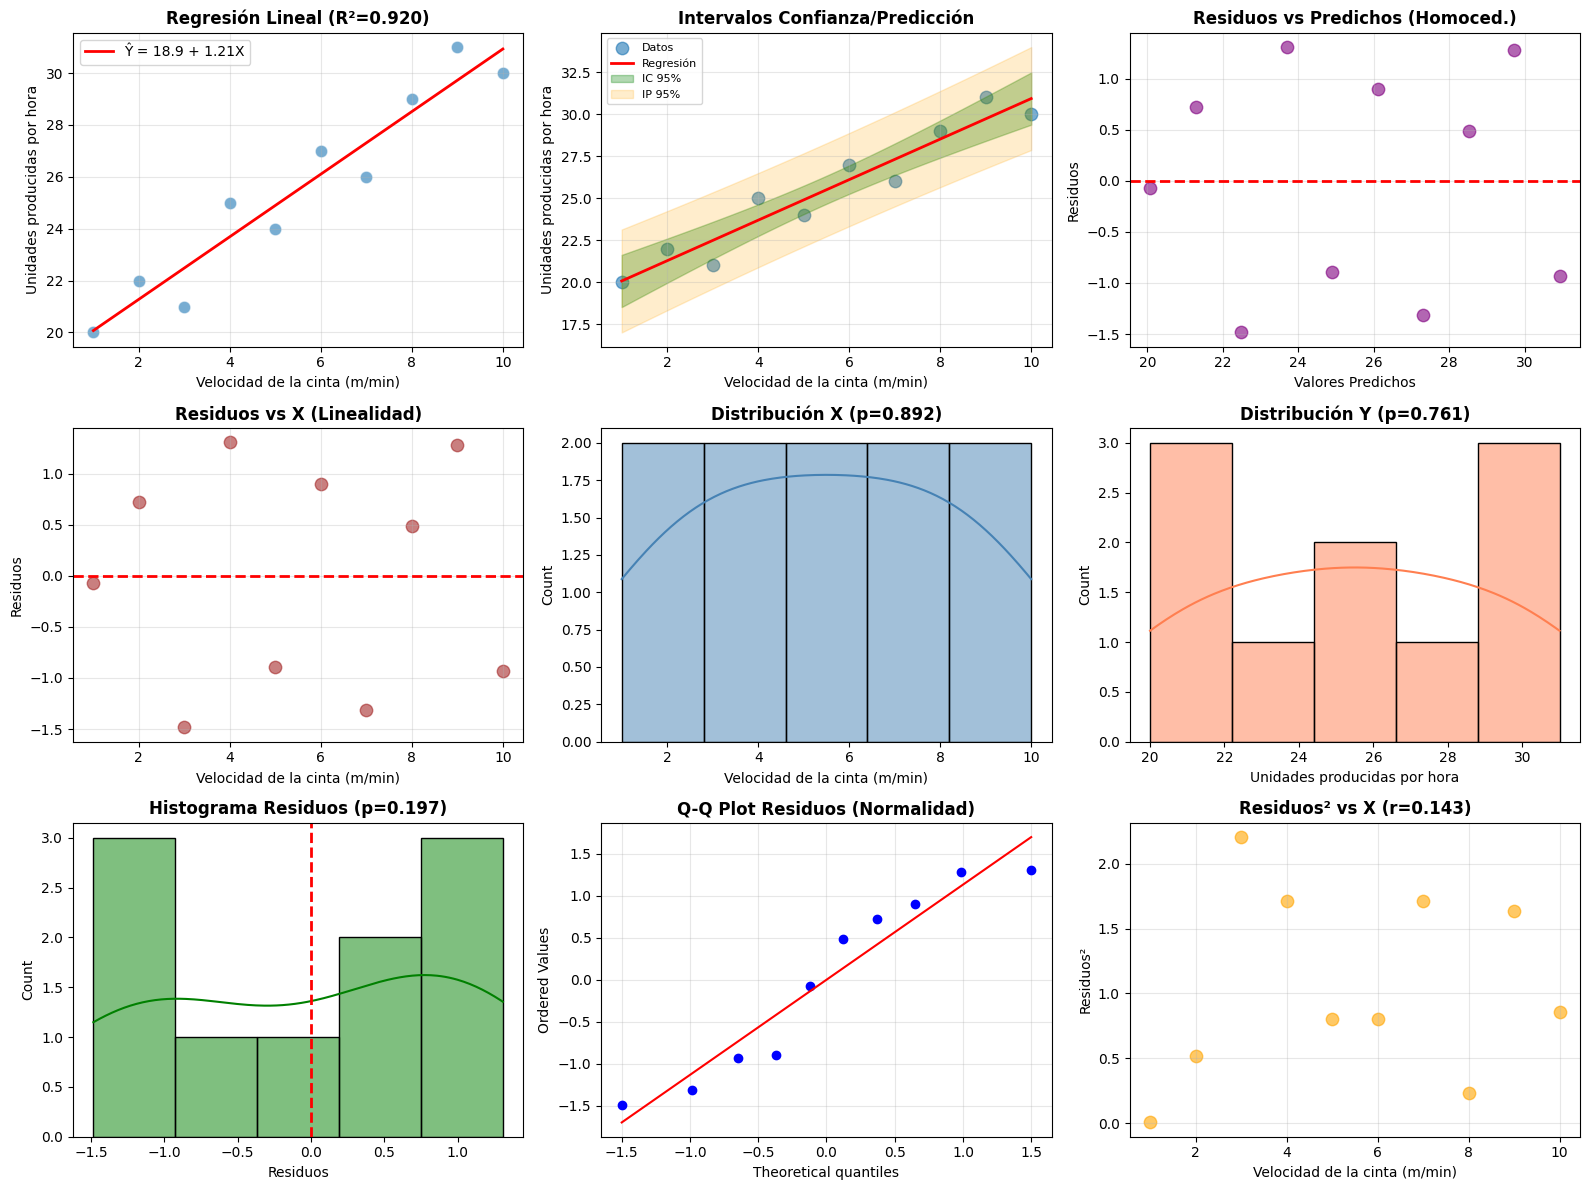


✓ ANÁLISIS COMPLETADO


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, t, f as f_dist, levene
from scipy import stats
import numpy as np

# --- DATOS ---
data = {
    'Velocidad de la cinta (m/min)': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Unidades producidas por hora': [20, 22, 21, 25, 24, 27, 26, 29, 31, 30]
}
df = pd.DataFrame(data)

var_x = 'Velocidad de la cinta (m/min)'
var_y = 'Unidades producidas por hora'
n, alfa = len(df), 0.05

print("=" * 70)
print("        ANÁLISIS DE REGRESIÓN LINEAL - ENSAMBLAJE")
print("=" * 70)
print(f"n={n} | α={alfa} | X={var_x} | Y={var_y}\n")

# --- ANÁLISIS DESCRIPTIVO ---
mean_x, mean_y = df[var_x].mean(), df[var_y].mean()
std_x, std_y = df[var_x].std(ddof=1), df[var_y].std(ddof=1)
min_x, max_x = df[var_x].min(), df[var_x].max()
min_y, max_y = df[var_y].min(), df[var_y].max()

# Correlaciones y Normalidad
pearson = df[var_x].corr(df[var_y])
spearman = df[var_x].corr(df[var_y], method='spearman')
shapiro_x = shapiro(df[var_x])
shapiro_y = shapiro(df[var_y])

print("--- ESTADÍSTICAS DESCRIPTIVAS Y CORRELACIÓN ---")
print(f"X: μ={mean_x:.2f}, σ={std_x:.2f}, rango=[{min_x}, {max_x}]")
print(f"Y: μ={mean_y:.2f}, σ={std_y:.2f}, rango=[{min_y}, {max_y}]")
print(f"\nNormalidad (Shapiro-Wilk):")
print(f"  X: p={shapiro_x.pvalue:.4f} {'✓ Normal' if shapiro_x.pvalue > alfa else '✗ No normal'}")
print(f"  Y: p={shapiro_y.pvalue:.4f} {'✓ Normal' if shapiro_y.pvalue > alfa else '✗ No normal'}")
print(f"\nCorrelación: Pearson={pearson:.4f} | Spearman={spearman:.4f}")
print(f"Magnitud: {'Fuerte' if abs(pearson) > 0.7 else 'Moderada' if abs(pearson) > 0.4 else 'Débil'} | Dirección: {'Positiva' if pearson > 0 else 'Negativa'}")

# --- PRUEBA DE HIPÓTESIS PARA CORRELACIÓN ---
gl = n - 2
t_corr = pearson * np.sqrt(n - 2) / np.sqrt(1 - pearson**2)
p_corr = t.sf(abs(t_corr), gl) * 2
t_crit_corr = t.ppf(1 - alfa/2, gl)

print(f"\n--- PRUEBA DE CORRELACIÓN ---")
print(f"H₀: ρ=0 vs H₁: ρ≠0 | t={t_corr:.3f}, t_crit=±{t_crit_corr:.3f}, p={p_corr:.4f}")
print(f"Decisión: {'✓ Rechazar H₀ - Correlación SIGNIFICATIVA' if p_corr < alfa else '✗ No rechazar H₀'}")

# --- REGRESIÓN Y PRUEBAS ---
b1 = pearson * (std_y / std_x)
b0 = mean_y - b1 * mean_x
df['y_pred'] = b0 + b1 * df[var_x]
df['residuos'] = df[var_y] - df['y_pred']

# Errores y pruebas
SSE = ((df[var_y] - df['y_pred']) ** 2).sum()
SS_Total = ((df[var_y] - mean_y) ** 2).sum()
SSR = SS_Total - SSE
s_yx = np.sqrt(SSE / (n - 2))
suma_desv_x = ((df[var_x] - mean_x) ** 2).sum()
s_b = s_yx / np.sqrt(suma_desv_x)
r2 = 1 - (SSE / SS_Total)

# Estadísticos t y F
t_calc = b1 / s_b
p_val_t = t.sf(abs(t_calc), gl) * 2  # dos colas
t_crit_pend = t.ppf(1 - alfa/2, gl)
F_calc = (SSR / 1) / (SSE / gl)
p_val_f = f_dist.sf(F_calc, 1, gl)

print(f"\n--- MODELO DE REGRESIÓN ---")
print(f"Ecuación: Ŷ = {b0:.4f} + {b1:.4f}X")
print(f"  b₀ (intersección): {b0:.4f} → Unidades base sin velocidad de cinta (cuando X=0)")
print(f"  b₁ (pendiente): {b1:.4f} → Por cada unidad adicional de {var_x}, +{b1:.4f} {var_y}")
print(f"\nBondad de ajuste:")
print(f"  R² = {r2:.4f} ({r2*100:.1f}% variabilidad explicada)")
print(f"  Error estándar (s_y,x) = {s_yx:.4f}")

print(f"\n--- PRUEBAS DE SIGNIFICANCIA (α={alfa}) ---")
print(f"1. Pendiente: H₀: β=0 vs H₁: β≠0")
print(f"   t={t_calc:.3f}, t_crit=±{t_crit_pend:.3f}, p={p_val_t:.4f}")
print(f"   → {'✓ Pendiente SIGNIFICATIVA' if p_val_t < alfa else '✗ Pendiente NO significativa'}")
print(f"\n2. Modelo (ANOVA): H₀: modelo no significativo vs H₁: modelo significativo")
print(f"   F={F_calc:.3f}, p={p_val_f:.6f}")
print(f"   → {'✓ Modelo SIGNIFICATIVO' if p_val_f < alfa else '✗ Modelo NO significativo'}")

# --- TABLA ANOVA ---
print(f"\n--- TABLA ANOVA ---")
print(f"{'Fuente':<12} {'SS':<12} {'gl':<6} {'MS':<12} {'F':<10} {'p-valor':<10}")
print("-" * 62)
print(f"{'Regresión':<12} {SSR:<12.4f} {1:<6} {SSR:<12.4f} {F_calc:<10.3f} {p_val_f:<10.6f}")
print(f"{'Error':<12} {SSE:<12.4f} {gl:<6} {SSE/gl:<12.4f}")
print(f"{'Total':<12} {SS_Total:<12.4f} {n-1:<6}")

# --- SUPUESTOS DEL MODELO ---
print(f"\n{'='*70}")
print("--- VALIDACIÓN DE SUPUESTOS DEL MODELO ---")
print(f"{'='*70}")

# 1. LINEALIDAD (visual - revisar gráfico)
print(f"\n1. LINEALIDAD:")
print(f"   • Correlación alta sugiere relación lineal: r={pearson:.4f}")
print(f"   • Revisar diagrama de dispersión para confirmar")
print(f"   → {'✓ Supuesto plausible' if abs(pearson) > 0.5 else '⚠ Revisar gráfico - correlación débil'}")

# 2. INDEPENDENCIA (no se puede probar con estos datos transversales)
print(f"\n2. INDEPENDENCIA:")
print(f"   • No hay orden temporal en los datos")
print(f"   • Asumimos observaciones independientes entre las mediciones")
print(f"   → ✓ Supuesto asumido (datos transversales)")

# 3. NORMALIDAD DE RESIDUOS
shapiro_res = shapiro(df['residuos'])
print(f"\n3. NORMALIDAD DE RESIDUOS:")
print(f"   • Shapiro-Wilk: W={shapiro_res.statistic:.4f}, p={shapiro_res.pvalue:.4f}")
print(f"   • Media residuos: {df['residuos'].mean():.4f} (debe ≈ 0)")
print(f"   → {'✓ Residuos normales' if shapiro_res.pvalue > alfa else '⚠ Residuos NO normales'}")

# 4. HOMOCEDASTICIDAD (varianza constante)
df['res_std'] = df['residuos'] / s_yx
# Prueba de Breusch-Pagan simplificada: correlación entre residuos² y X
residuos_cuadrados = df['residuos'] ** 2
corr_hetero = df[var_x].corr(residuos_cuadrados)
# Dividir en dos grupos y aplicar Levene
mediana_x = df[var_x].median()
grupo1 = df[df[var_x] <= mediana_x]['residuos'].abs()
grupo2 = df[df[var_x] > mediana_x]['residuos'].abs()
levene_stat, levene_p = levene(grupo1, grupo2)

print(f"\n4. HOMOCEDASTICIDAD (varianza constante):")
print(f"   • Test de Levene: W={levene_stat:.4f}, p={levene_p:.4f}")
print(f"   • Correlación |residuos| vs X: {corr_hetero:.4f}")
print(f"   • Revisar gráfico 'Residuos vs Predichos' (debe ser aleatorio)")
if levene_p > alfa and abs(corr_hetero) < 0.3:
    print(f"   → ✓ Homocedasticidad cumplida")
elif levene_p <= alfa:
    print(f"   → ⚠ Posible heterocedasticidad detectada")
else:
    print(f"   → ⚠ Revisar gráficamente - correlación moderada")

# 5. OUTLIERS
outliers = df[np.abs(df['res_std']) > 2.5]
print(f"\n5. VALORES ATÍPICOS (OUTLIERS):")
print(f"   • Outliers (|res_std| > 2.5): {len(outliers)}/{n} ({len(outliers)/n*100:.1f}%)")
if len(outliers) > 0:
    for idx, row in outliers.iterrows():
        print(f"     • Fila {idx}: res_std={row['res_std']:.2f}") # Changed from 'Representantes de ventas'
print(f"   → {'✓ Sin outliers significativos' if len(outliers) == 0 else '⚠ Revisar outliers identificados'}")

# --- RESUMEN DE SUPUESTOS ---
supuestos_ok = (
    abs(pearson) > 0.5 and
    shapiro_res.pvalue > alfa and
    (levene_p > alfa and abs(corr_hetero) < 0.3) and
    len(outliers) <= n * 0.15
)

print(f"\n{'='*70}")
print(f"RESUMEN DE SUPUESTOS: {'✓ TODOS CUMPLIDOS' if supuestos_ok else '⚠ REVISAR SUPUESTOS'}")
print(f"{'='*70}")

# --- INTERVALOS (ejemplos) ---
t_crit = t.ppf(1 - alfa/2, gl)
x_ejemplos = [df[var_x].min(), df[var_x].mean(), df[var_x].median(), df[var_x].max()] # Using actual data range for examples

print(f"\n--- INTERVALOS DE CONFIANZA Y PREDICCIÓN (95%) ---")
print(f"{'X':<8} {'Ŷ':<10} {'IC Media':<25} {'IP Individual':<25}")
print("-" * 68)

for x_val in x_ejemplos:
    y_pred = b0 + b1 * x_val

    # IC para la media
    error_conf = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desv_x))
    margen_conf = t_crit * s_yx * error_conf
    ic_inf, ic_sup = y_pred - margen_conf, y_pred + margen_conf

    # IP individual
    error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desv_x))
    margen_pred = t_crit * s_yx * error_pred
    ip_inf, ip_sup = y_pred - margen_pred, y_pred + margen_pred

    print(f"{x_val:<8.1f} {y_pred:<10.2f} [{ic_inf:.1f}, {ic_sup:.1f}]{'':>10} [{ip_inf:.1f}, {ip_sup:.1f}]")

# --- EVALUACIÓN DE TRANSFORMACIÓN ---
print(f"\n--- ¿NECESITA TRANSFORMACIÓN DE DATOS? ---")
necesita = False
razones = []

if shapiro_x.pvalue <= alfa or shapiro_y.pvalue <= alfa:
    razones.append("Variables originales no normales")
    necesita = True
if shapiro_res.pvalue <= alfa:
    razones.append("Residuos no normales")
    necesita = True
if levene_p <= alfa or abs(corr_hetero) >= 0.3:
    razones.append("Posible heterocedasticidad")
    necesita = True
if abs(pearson) < 0.5:
    razones.append(f"Correlación débil (r={pearson:.3f})")
    necesita = True
if len(outliers) > n * 0.15:
    razones.append(f"Exceso de outliers ({len(outliers)})")
    necesita = True

if necesita:
    print("⚠ CONSIDERAR TRANSFORMACIÓN:")
    for r in razones:
        print(f"  • {r}")
    print("\n  Transformaciones sugeridas:")
    print("    - log(Y): reduce asimetría positiva, estabiliza varianza")
    print("    - √Y: para datos de conteo con varianza proporcional a media")
    print("    - 1/Y: para relaciones no lineales decrecientes")
    print("    - Box-Cox: encuentra transformación óptima automáticamente")
else:
    print("✓ NO NECESARIA - Todos los supuestos cumplidos adecuadamente")

# --- RESUMEN EJECUTIVO ---
print(f"\n{'='*70}")
print("                        RESUMEN EJECUTIVO")
print(f"{'='*70}")
print(f"""
📊 MODELO: Ŷ = {b0:.2f} + {b1:.3f}X
   Interpretación: Por cada unidad adicional de {var_x} → +{b1:.3f} {var_y}

📈 BONDAD DE AJUSTE:
   • R² = {r2:.3f} ({r2*100:.1f}% variabilidad explicada)
   • Correlación {'fuerte' if abs(pearson) > 0.7 else 'moderada' if abs(pearson) > 0.4 else 'débil'}: r = {pearson:.3f}
   • Error típico de predicción: ±{s_yx:.2f} {var_y}

✅ SIGNIFICANCIA ESTADÍSTICA:
   • Correlación: {'✓ Significativa' if p_corr < alfa else '✗ No significativa'} (p={p_corr:.4f})
   • Pendiente: {'✓ Significativa' if p_val_t < alfa else '✗ No significativa'} (p={p_val_t:.4f})
   • Modelo: {'✓ Significativo' if p_val_f < alfa else '✗ No significativo'} (p={p_val_f:.6f})

🔍 VALIDACIÓN DE SUPUESTOS:
   • Linealidad: {'✓' if abs(pearson) > 0.5 else '⚠'}
   • Independencia: ✓ (asumido)
   • Normalidad residuos: {'✓' if shapiro_res.pvalue > alfa else '⚠'} (p={shapiro_res.pvalue:.3f})
   • Homocedasticidad: {'✓' if levene_p > alfa and abs(corr_hetero) < 0.3 else '⚠'} (Levene p={levene_p:.3f})
   • Outliers: {len(outliers)}/{n} → {'✓ Aceptable' if len(outliers) <= n*0.15 else '⚠ Revisar'}

💡 CONCLUSIÓN:""")

if p_val_t < alfa and p_val_f < alfa and supuestos_ok:
    print(f"""   ✓✓ EL MODELO ES VÁLIDO Y CONFIABLE PARA PREDICCIONES

   El modelo cumple todos los supuestos y las pruebas estadísticas confirman
   que {var_x} es un predictor significativo de {var_y}.
   El modelo explica {r2*100:.1f}% de la variabilidad y puede utilizarse con
   confianza para:
   • Predecir {var_y} futuras basadas en {var_x} planificada
   • Establecer objetivos de {var_x} para alcanzar metas de {var_y}

   Recomendación: IMPLEMENTAR este modelo en la planificación de la línea de ensamblaje.
""")
elif p_val_t < alfa and p_val_f < alfa:
    print(f"""   ⚠ MODELO SIGNIFICATIVO pero con SUPUESTOS COMPROMETIDOS

   Aunque las pruebas son significativas, algunos supuestos no se cumplen
   completamente. Usar con PRECAUCIÓN y considerar:
   • Transformación de datos (ver recomendaciones arriba)
   • Recolectar más observaciones
   • Investigar outliers identificados
""")
else:
    print(f"""   ✗ MODELO CON LIMITACIONES SIGNIFICATIVAS

   El modelo NO es estadísticamente confiable. Se recomienda:
   • Recolectar más datos o mejorar calidad de datos
   • Considerar otras variables explicativas
   • Explorar modelos alternativos (no lineal, multivariado)
""")

print("\n" + "=" * 70)

# --- GRÁFICOS ---
fig = plt.figure(figsize=(16, 12))

# 1. Dispersión con regresión
ax1 = plt.subplot(3, 3, 1)
sns.scatterplot(x=var_x, y=var_y, data=df, s=80, alpha=0.6)
x_line = np.linspace(df[var_x].min(), df[var_x].max(), 100)
y_line = b0 + b1 * x_line
plt.plot(x_line, y_line, 'r-', lw=2, label=f'Ŷ = {b0:.1f} + {b1:.2f}X')
plt.title(f'Regresión Lineal (R²={r2:.3f})', fontweight='bold')
plt.xlabel(var_x)
plt.ylabel(var_y)
plt.legend()
plt.grid(alpha=0.3)

# 2. Regresión con intervalos
ax2 = plt.subplot(3, 3, 2)
plt.scatter(df[var_x], df[var_y], s=80, alpha=0.6, label='Datos')
plt.plot(x_line, y_line, 'r-', lw=2, label='Regresión')

# Calcular bandas
ic_lower, ic_upper = [], []
ip_lower, ip_upper = [], []
for x_val in x_line:
    y_p = b0 + b1 * x_val
    e_conf = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desv_x))
    e_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desv_x))
    ic_lower.append(y_p - t_crit * s_yx * e_conf)
    ic_upper.append(y_p + t_crit * s_yx * e_conf)
    ip_lower.append(y_p - t_crit * s_yx * e_pred)
    ip_upper.append(y_p + t_crit * s_yx * e_pred)

plt.fill_between(x_line, ic_lower, ic_upper, alpha=0.3, color='green', label='IC 95%')
plt.fill_between(x_line, ip_lower, ip_upper, alpha=0.2, color='orange', label='IP 95%')
plt.title('Intervalos Confianza/Predicción', fontweight='bold')
plt.xlabel(var_x)
plt.ylabel(var_y)
plt.legend(fontsize=8)
plt.grid(alpha=0.3)

# 3. Residuos vs Predichos (HOMOCEDASTICIDAD)
ax3 = plt.subplot(3, 3, 3)
plt.scatter(df['y_pred'], df['residuos'], s=80, alpha=0.6, color='purple')
plt.axhline(0, color='r', linestyle='--', lw=2)
plt.title('Residuos vs Predichos (Homoced.)', fontweight='bold')
plt.xlabel('Valores Predichos')
plt.ylabel('Residuos')
plt.grid(alpha=0.3)

# 4. Residuos vs X
ax4 = plt.subplot(3, 3, 4)
plt.scatter(df[var_x], df['residuos'], s=80, alpha=0.6, color='brown')
plt.axhline(0, color='r', linestyle='--', lw=2)
plt.title('Residuos vs X (Linealidad)', fontweight='bold')
plt.xlabel(var_x)
plt.ylabel('Residuos')
plt.grid(alpha=0.3)

# 5. Histograma X
ax5 = plt.subplot(3, 3, 5)
sns.histplot(df[var_x], kde=True, color='steelblue')
plt.title(f'Distribución X (p={shapiro_x.pvalue:.3f})', fontweight='bold')
plt.xlabel(var_x)

# 6. Histograma Y
ax6 = plt.subplot(3, 3, 6)
sns.histplot(df[var_y], kde=True, color='coral')
plt.title(f'Distribución Y (p={shapiro_y.pvalue:.3f})', fontweight='bold')
plt.xlabel(var_y)

# 7. Histograma Residuos
ax7 = plt.subplot(3, 3, 7)
sns.histplot(df['residuos'], kde=True, color='green')
plt.axvline(0, color='r', linestyle='--', lw=2)
plt.title(f'Histograma Residuos (p={shapiro_res.pvalue:.3f})', fontweight='bold')
plt.xlabel('Residuos')

# 8. Q-Q Plot Residuos
ax8 = plt.subplot(3, 3, 8)
stats.probplot(df['residuos'], dist="norm", plot=ax8)
plt.title('Q-Q Plot Residuos (Normalidad)', fontweight='bold')
plt.grid(alpha=0.3)

# 9. Gráfico de dispersión de residuos² vs X (Heterocedasticidad visual)
ax9 = plt.subplot(3, 3, 9)
plt.scatter(df[var_x], residuos_cuadrados, s=80, alpha=0.6, color='orange')
plt.title(f'Residuos² vs X (r={corr_hetero:.3f})', fontweight='bold')
plt.xlabel(var_x)
plt.ylabel('Residuos²')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ ANÁLISIS COMPLETADO")